In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Expected Period: 1.3927362637033918
1.3900644 -0.0019184276111882783


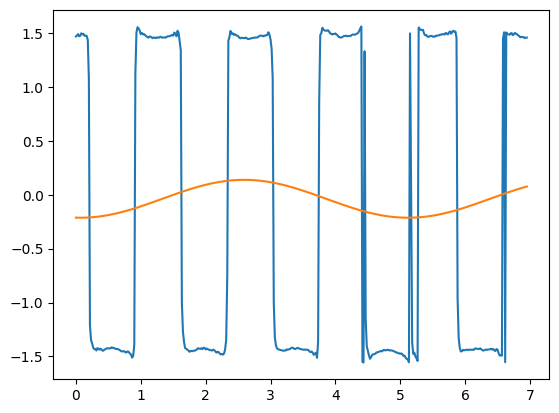

In [34]:
data10 = pd.read_csv("./data/3010.txt")
data15 = pd.read_csv("./data/3015.txt")
data30 = pd.read_csv("./data/3030.txt")
data45 = pd.read_csv("./data/3045.txt")
data60 = pd.read_csv("./data/3060.txt")
data75 = pd.read_csv("./data/3075.txt")
data90 = pd.read_csv("./data/3090.txt")

# datasets = [data10, data15, data30, data45, data60, data75, data90]
datasets = [data10]
m = 40 * 0.001 # kg
l = 48.2 * 0.01 # m
g = 9.81 # m / s^2
exp_period = 2 * np.pi * np.sqrt(l / g)

def cosine_func(x, amplitude, frequency, phase, offset):
    return amplitude * np.cos(frequency * x + phase) + offset

print(f"Expected Period: {exp_period}")


for dataset in datasets:
    x = np.array(dataset['x'])
    y = np.array(dataset['y'])
    theta = np.atan(x/y)
    t = np.array(dataset['t'])
    num_oscillations = 5
    period = (t[-1] - t[0]) / num_oscillations
    err = (period - exp_period) / exp_period

    popt, pcov = curve_fit(cosine_func, t, theta)
    fit_amplitude, fit_frequency, fit_phase, fit_offset = popt

    created_t = np.linspace(t[0], t[-1], len(t))
    created_theta = np.array([cosine_func(t, fit_amplitude, fit_frequency, fit_phase, fit_offset) for t in created_t])

    plt.plot(t, theta)
    plt.plot(created_t, created_theta)

    print(period, err)
